**Importing the Libraries**


In [2]:
import torch
import torch.nn as nn
import torchvision
from torchvision.datasets import CIFAR10
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
from torchvision.transforms import transforms

**Transforming the Data**

In [51]:
from PIL.Image import Transform
# Composing (defining the list of transformation into our data)
transformation = transforms.Compose([
    # 1 st transforming data toTensor
    transforms.ToTensor(),
    # Normalization usually put in range of (-1,1) so take mean and std for (h,w,c) = 0.5,0.5,0.5
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)),
])

# transforming train and validation
train_trans = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])
val_trans = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

**Transforming our CIFAR10 Dataset**

In [77]:
# forming our dataset
training_data = CIFAR10(root ="/content/Data",train=True,transform=train_trans)
testing_data = CIFAR10(root ="/content/Data",train=False,transform=val_trans)


**Loading our CIFAR10 Dataset**

In [78]:
# Loading the data
TrainLoader = DataLoader(training_data,batch_size=64,shuffle=True)
TestLoader = DataLoader(testing_data,batch_size=64)

In [79]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


**Building CNN Architecture**

In [88]:
# Forming our CNN architecture
class CNN(nn.Module):
  def __init__(self):
    super(CNN,self).__init__()

    # convolution layer
    self.Convo_layer = nn.Sequential(
        # 1st Convolutional layer (3,32,32)   o/p = n-f+2p/s + 1  =32
        nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        ),
        nn.ReLU(),
        nn.MaxPool2d(
            kernel_size=2,
            stride=2,
        ),
        # conv2d --> ReLU --> MaxPool

        # 2nd convolution layer (32,16,16)   o/p = 2*in_channels = 64
        nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1,
        ),
        nn.ReLU(),
        nn.MaxPool2d(
            kernel_size=2,
            stride=2
        ),

        # 3rd Convolution layer (64,8,8) o/p = 2*in_channels = 128
        nn.Conv2d(
            in_channels=64,
            out_channels=128,
            kernel_size=3,
            padding=1
        ),
        nn.ReLU(),
        nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )
    )
        # o/p => (128,4,4) input in fc_layer = 128*4*4
    self.fully_connected_layer = nn.Sequential(
        # 1st layer
        nn.Linear(128*4*4,256),
        nn.ReLU(),
        nn.BatchNorm1d(256),
        # 2nd layer
        nn.Linear(256,10)
        # as we will use crossEntropyLoss having sigmoid function already so no need to define sigmoid here
    )
  def forward(self,x):
    x = self.Convo_layer(x)
    x=x.view(x.size(0),-1)  # flattening (Fixed x.Size to x.size in previous step)
    # x.size => batch size   -1 remaining dimension ==> 128*4*4
    # x = (64,128*4*4)  means 64 rows (images) having 128*4*4 columns
    return self.fully_connected_layer(x)


**Initializing our Model**

In [89]:
model = CNN()
model.to(device)
optimizer = optim.Adam(model.parameters())
loss = nn.CrossEntropyLoss()

**Training and validating our Model**

In [93]:
# Training the model
epochs = 10
training_loss = []
valid_loss = []
best_val_loss=float("inf")
for epoch in range(epochs):
  model.train()
  running_loss = 0.0
  for images , labels in TrainLoader:
    images,labels = images.to(device),labels.to(device)
    optimizer.zero_grad()
    output = model.forward(images)
    l=loss(output , labels)
    # if loss (l)
    l.backward()
    optimizer.step()
    running_loss+=l.item()
  training_loss.append(running_loss)


  # validating our model
  model.eval()
  validation_loss = 0.0
  with torch.no_grad():
    for images,labels in TestLoader:
      images,labels = images.to(device),labels.to(device)
      output = model.forward(images)
      l=loss(output,labels)
      validation_loss+=l.item()
  valid_loss.append(validation_loss)

  print(f'{epoch+1}/{epochs} training : {running_loss/len(TestLoader)}  validation : {validation_loss/len(TestLoader)}')
  if best_val_loss>validation_loss:
    best_val_loss=validation_loss
    torch.save(model.state_dict(),"CnnBestModel.pt")


1/10 training : 2.578493768242514  validation : 0.6243775509724951
2/10 training : 2.5351863073505414  validation : 0.5736947706930197
3/10 training : 2.4270481906688897  validation : 0.582487491285725
4/10 training : 2.339595339480479  validation : 0.598773676119033
5/10 training : 2.27508078430109  validation : 0.5915269868768704
6/10 training : 2.194895860875488  validation : 0.567077097619415
7/10 training : 2.1360779356235153  validation : 0.5766689614125877
8/10 training : 2.0797655048548798  validation : 0.5738744637009444
9/10 training : 2.1544976599846675  validation : 0.5799270314965278
10/10 training : 2.025233488268913  validation : 0.5698500245240083


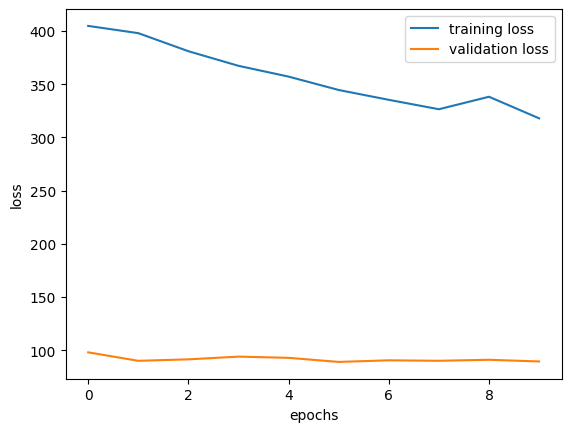

In [94]:
data = pd.DataFrame({
    "training_loss":training_loss,
    "valid_loss":valid_loss,
})
plt.plot(data["training_loss"],label="training loss")
plt.plot(data["valid_loss"],label="validation loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()


In [95]:
model.load_state_dict(torch.load("CnnBestModel.pt"))
model.eval()
correct_pred = 0
total_labels=0
with torch.no_grad():
  for images , labels in TestLoader:
    images,labels = images.to(device), labels.to(device)
    output = model.forward(images)
    _,pred = torch.max(output,1)
    correct_pred += (pred == labels).sum().item()
    total_labels = len(TestLoader)
print(f'accuracy of prediction : {correct_pred/total_labels}')

accuracy of prediction : 51.77070063694268
